# Targeted EDA: Missing Values and Position Bias
 
These feed directly into:
1. Missing value indicator features (Section 2.4)
2. Position-debiased hotel quality features (Section 2.6)
3. Bias investigation (Phase 4)

In [1]:
import sys
from pathlib import Path
 
cwd = Path(".").resolve()
REPO_ROOT = cwd if (cwd / ".git").exists() else cwd.parent
sys.path.insert(0, str(REPO_ROOT))
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
 
from src.utils import load_train
 
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100
 
df = load_train()
print(f"{len(df):,} rows, {df['srch_id'].nunique():,} searches")

4,958,347 rows, 199,795 searches


### 1. Missing Value Analysis

In [2]:
"""
## 1. Missing Value Analysis
 
Per-column null percentages, informative missingness patterns, and
implications for feature engineering.
"""
 
null_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
null_cols = null_pct[null_pct > 0]
 
print("Columns with missing values:")
print(null_cols.round(1).to_string())
print(f"\n{len(null_cols)} of {df.shape[1]} columns have missing values")

Columns with missing values:
comp1_rate_percent_diff      98.1
comp6_rate_percent_diff      98.1
comp1_rate                   97.6
comp1_inv                    97.4
comp4_rate_percent_diff      97.4
gross_bookings_usd           97.2
comp7_rate_percent_diff      97.2
comp6_rate                   95.2
visitor_hist_starrating      94.9
visitor_hist_adr_usd         94.9
comp6_inv                    94.7
comp4_rate                   93.8
comp7_rate                   93.6
srch_query_affinity_score    93.6
comp4_inv                    93.1
comp7_inv                    92.8
comp3_rate_percent_diff      90.5
comp2_rate_percent_diff      88.8
comp8_rate_percent_diff      87.6
comp5_rate_percent_diff      83.0
comp3_rate                   69.1
comp3_inv                    66.7
comp8_rate                   61.3
comp8_inv                    59.9
comp2_rate                   59.2
comp2_inv                    57.0
comp5_rate                   55.2
comp5_inv                    52.4
orig_destination_di

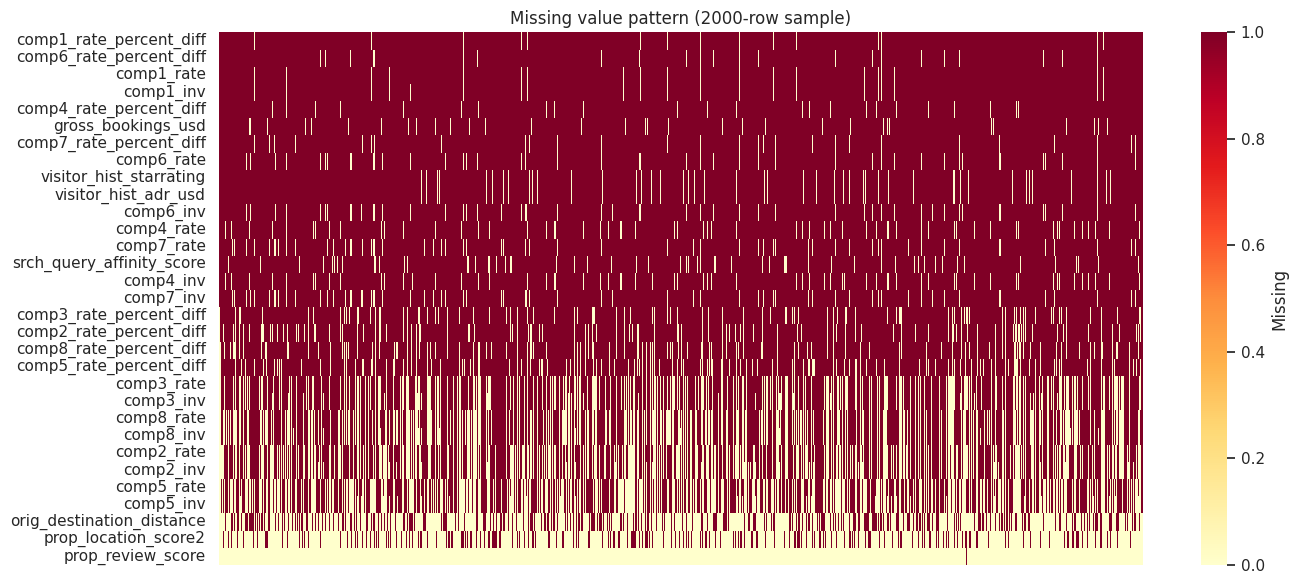

In [3]:
# --- Null percentage heatmap ---
fig, ax = plt.subplots(figsize=(14, 6))
null_matrix = df[null_cols.index].isnull().astype(int)
# Sample rows for visualization (full dataset too large for heatmap)
sample_idx = np.random.RandomState(42).choice(len(null_matrix), size=2000, replace=False)
sns.heatmap(
    null_matrix.iloc[sample_idx].T,
    cbar_kws={"label": "Missing"},
    yticklabels=True,
    xticklabels=False,
    ax=ax,
    cmap="YlOrRd",
)
ax.set_title("Missing value pattern (2000-row sample)")
plt.tight_layout()
plt.show()

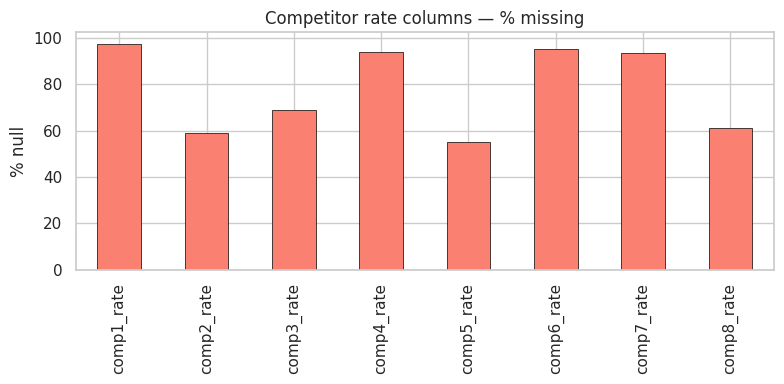


Competitor null percentages:
comp1_rate    97.6
comp2_rate    59.2
comp3_rate    69.1
comp4_rate    93.8
comp5_rate    55.2
comp6_rate    95.2
comp7_rate    93.6
comp8_rate    61.3


In [4]:
# --- Competitor data sparsity ---
comp_rate_cols = [f"comp{i}_rate" for i in range(1, 9)]
comp_null_pct = df[comp_rate_cols].isnull().mean() * 100
 
fig, ax = plt.subplots(figsize=(8, 4))
comp_null_pct.plot.bar(ax=ax, color="salmon", edgecolor="black", linewidth=0.5)
ax.set_title("Competitor rate columns — % missing")
ax.set_ylabel("% null")
ax.set_xlabel("")
plt.tight_layout()
plt.show()
 
print("\nCompetitor null percentages:")
print(comp_null_pct.round(1).to_string())

In [5]:
# --- Is missingness informative? ---
# Compare booking rates: visitors WITH history vs WITHOUT
has_hist = df["visitor_hist_starrating"].notna()
rate_with = df.loc[has_hist, "booking_bool"].mean()
rate_without = df.loc[~has_hist, "booking_bool"].mean()
 
print(f"\nBooking rate WITH visitor history:    {rate_with:.4f} ({rate_with*100:.2f}%)")
print(f"Booking rate WITHOUT visitor history: {rate_without:.4f} ({rate_without*100:.2f}%)")
print(f"Ratio: {rate_with / rate_without:.2f}x")


Booking rate WITH visitor history:    0.0361 (3.61%)
Booking rate WITHOUT visitor history: 0.0275 (2.75%)
Ratio: 1.31x


In [6]:
# Compare booking rates by affinity-score availability
has_affinity = df["srch_query_affinity_score"].notna()
rate_aff = df.loc[has_affinity, "booking_bool"].mean()
rate_no_aff = df.loc[~has_affinity, "booking_bool"].mean()
 
print(f"\nBooking rate WITH affinity score:     {rate_aff:.4f}")
print(f"Booking rate WITHOUT affinity score:  {rate_no_aff:.4f}")


Booking rate WITH affinity score:     0.0343
Booking rate WITHOUT affinity score:  0.0275


In [7]:
# Compare booking rates by distance availability
has_dist = df["orig_destination_distance"].notna()
rate_dist = df.loc[has_dist, "booking_bool"].mean()
rate_no_dist = df.loc[~has_dist, "booking_bool"].mean()
 
print(f"\nBooking rate WITH distance:           {rate_dist:.4f}")
print(f"Booking rate WITHOUT distance:        {rate_no_dist:.4f}")


Booking rate WITH distance:           0.0280
Booking rate WITHOUT distance:        0.0278


In [8]:
# Competitor data: at least one competitor has data vs none
any_comp = df[comp_rate_cols].notna().any(axis=1)
rate_comp = df.loc[any_comp, "booking_bool"].mean()
rate_no_comp = df.loc[~any_comp, "booking_bool"].mean()
 
print(f"\nBooking rate WITH any comp data:      {rate_comp:.4f}")
print(f"Booking rate WITHOUT any comp data:   {rate_no_comp:.4f}")


Booking rate WITH any comp data:      0.0291
Booking rate WITHOUT any comp data:   0.0256


**Takeaway:** Nulls are strongly informative in this dataset. Visitors with purchase history book at a much higher rate. The presence of competitor data, affinity scores, and distance all correlate with booking behavior. Missing value indicator features (Section 2.4) are justified.

### 2. Position Bias Investigation

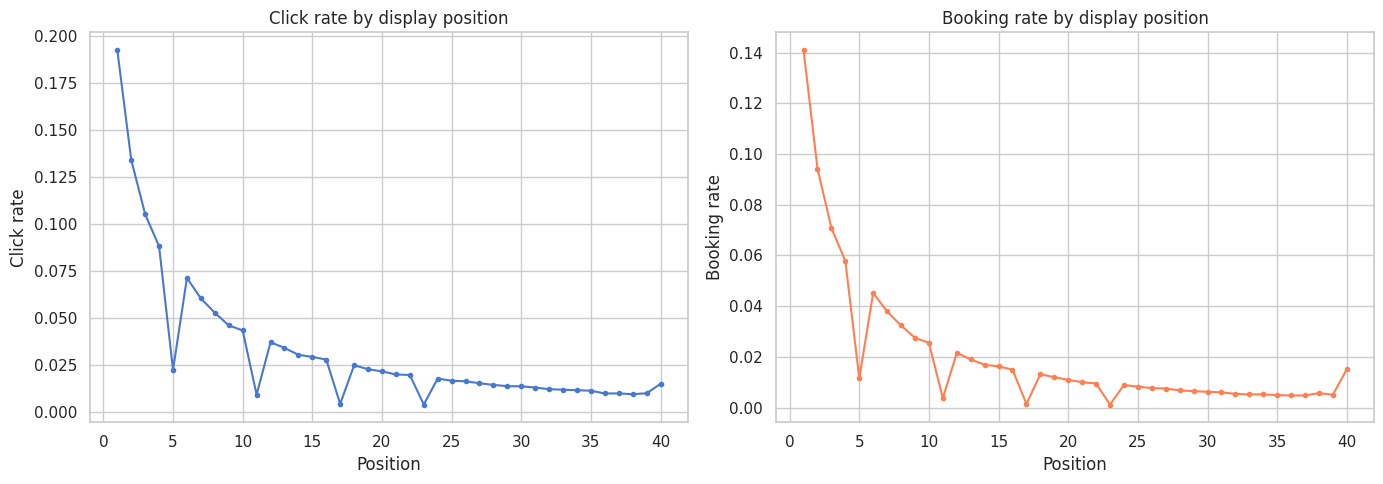

Position bias — click and booking rates for top positions:
          click_rate  booking_rate   count
position                                  
1             0.1925        0.1410  199415
2             0.1342        0.0943  199350
3             0.1053        0.0708  199355
4             0.0882        0.0579  193406
5             0.0226        0.0116    9312
6             0.0714        0.0452  199172
7             0.0605        0.0379  194769
8             0.0529        0.0324  190375
9             0.0462        0.0275  186236
10            0.0435        0.0255  173451


In [9]:
"""
## 2. Position Bias Investigation
 
Quantify how display position affects click and booking rates, and validate
the random_bool=1 subset for computing unbiased hotel quality features.
"""
 
# --- Click/booking rate by position ---
pos_rates = df.groupby("position").agg(
    click_rate=("click_bool", "mean"),
    booking_rate=("booking_bool", "mean"),
    count=("booking_bool", "size"),
)
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pos_rates["click_rate"].plot(ax=axes[0], marker="o", markersize=3, linewidth=1.5)
axes[0].set_title("Click rate by display position")
axes[0].set_xlabel("Position")
axes[0].set_ylabel("Click rate")
 
pos_rates["booking_rate"].plot(ax=axes[1], marker="o", markersize=3, linewidth=1.5, color="coral")
axes[1].set_title("Booking rate by display position")
axes[1].set_xlabel("Position")
axes[1].set_ylabel("Booking rate")
plt.tight_layout()
plt.show()
 
print("Position bias — click and booking rates for top positions:")
print(pos_rates.head(10).round(4).to_string())

In [10]:
# --- Random vs non-random comparison ---
random_rates = df.groupby("random_bool").agg(
    click_rate=("click_bool", "mean"),
    booking_rate=("booking_bool", "mean"),
    count=("booking_bool", "size"),
)
print("\nRandom vs non-random display:")
print(random_rates.round(4).to_string())


Random vs non-random display:
             click_rate  booking_rate    count
random_bool                                   
0                0.0440        0.0374  3491170
1                0.0466        0.0053  1467177


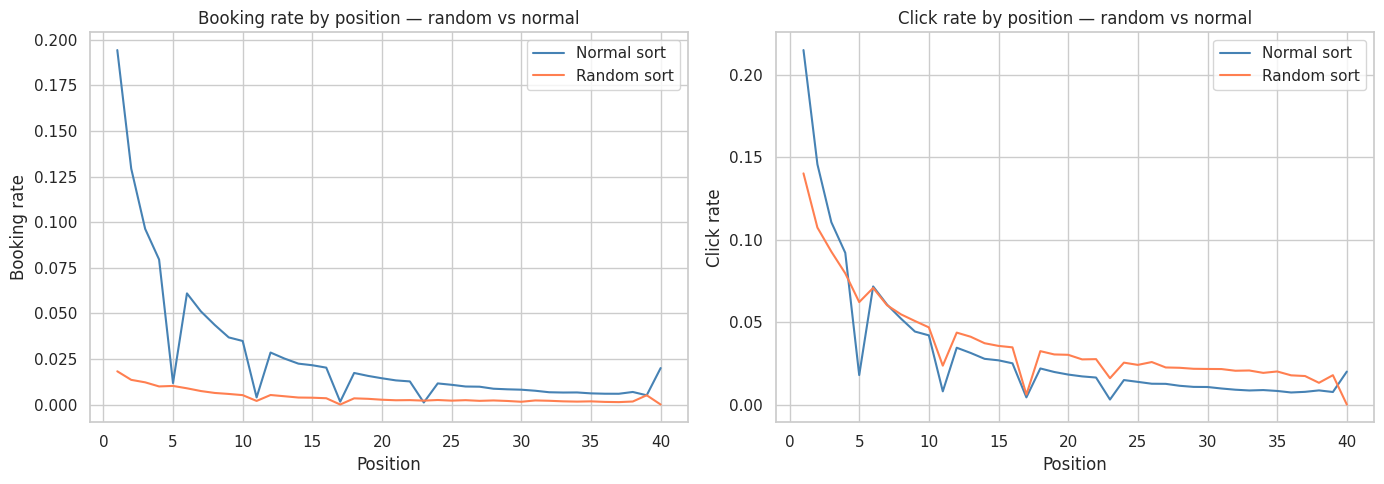

In [11]:
# --- Position effect within random vs non-random ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
for rb, label, color in [(0, "Normal sort", "steelblue"), (1, "Random sort", "coral")]:
    subset = df[df["random_bool"] == rb]
    rates = subset.groupby("position")["booking_rate" if "booking_rate" in subset.columns else "booking_bool"].mean()
    if "booking_rate" not in subset.columns:
        rates = subset.groupby("position")["booking_bool"].mean()
    rates.plot(ax=axes[0], label=label, color=color, linewidth=1.5)
 
axes[0].set_title("Booking rate by position — random vs normal")
axes[0].set_xlabel("Position")
axes[0].set_ylabel("Booking rate")
axes[0].legend()
 
for rb, label, color in [(0, "Normal sort", "steelblue"), (1, "Random sort", "coral")]:
    subset = df[df["random_bool"] == rb]
    rates = subset.groupby("position")["click_bool"].mean()
    rates.plot(ax=axes[1], label=label, color=color, linewidth=1.5)
 
axes[1].set_title("Click rate by position — random vs normal")
axes[1].set_xlabel("Position")
axes[1].set_ylabel("Click rate")
axes[1].legend()
plt.tight_layout()
plt.show()

In [12]:
# --- Quantify position bias ---
# In non-random results, position 1 gets disproportionate clicks
normal = df[df["random_bool"] == 0]
random = df[df["random_bool"] == 1]
 
normal_pos1_ctr = normal[normal["position"] == 1]["click_bool"].mean()
random_pos1_ctr = random[random["position"] == 1]["click_bool"].mean()
normal_all_ctr = normal["click_bool"].mean()
random_all_ctr = random["click_bool"].mean()
 
print(f"\nNormal sort — position 1 click rate:  {normal_pos1_ctr:.4f}")
print(f"Random sort — position 1 click rate:  {random_pos1_ctr:.4f}")
print(f"Normal sort — overall click rate:     {normal_all_ctr:.4f}")
print(f"Random sort — overall click rate:     {random_all_ctr:.4f}")
 
# random_bool split balance
rb_counts = df["random_bool"].value_counts()
print(f"\nrandom_bool distribution:")
print(f"  Normal (0): {rb_counts[0]:,} ({rb_counts[0]/len(df)*100:.1f}%)")
print(f"  Random (1): {rb_counts[1]:,} ({rb_counts[1]/len(df)*100:.1f}%)")


Normal sort — position 1 click rate:  0.2152
Random sort — position 1 click rate:  0.1403
Normal sort — overall click rate:     0.0440
Random sort — overall click rate:     0.0466

random_bool distribution:
  Normal (0): 3,491,170 (70.4%)
  Random (1): 1,467,177 (29.6%)


**Takeaway:** Strong position bias exists in non-random results — earlier positions get far more clicks regardless of hotel quality. In the random subset, click rates are flatter across positions, confirming the randomization is clean. The random_bool=1 subset (~30% of rows) is suitable for computing position-debiased hotel quality features (Section 2.6).

Targeted EDA complete.